# 8. Model Monitoring & Drift Detection

This notebook provides a **production-ready monitoring template** for the hotel booking
cancellation model. It answers the question: *is the deployed model still behaving as
expected on new bookings?*

**Monitoring strategy**: compare incoming production batches against the held-out test set
(June–August 2017) used as the baseline distribution.

**Prerequisites**: `make train && make benchmark` — all inputs come from
`reports/test_predictions_for_powerbi.csv` (pre-computed; no retraining here).

> In a live deployment, replace the *batch* DataFrames with real inference logs
> from your prediction database or feature store.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

cfg    = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT   = project_root()

# ── Load test predictions (baseline + simulated production batches) ───────────
df = pd.read_csv(ROOT / "reports" / "test_predictions_for_powerbi.csv")

# Split by arrival month — June = baseline, July/August = production batches
MONTH_ORDER = ["June", "July", "August"]
baseline = df[df["arrival_date_month"] == "June"].copy()
batch1   = df[df["arrival_date_month"] == "July"].copy()
batch2   = df[df["arrival_date_month"] == "August"].copy()

BATCHES = {"Baseline (June)": baseline, "Batch 1 (July)": batch1, "Batch 2 (Aug)": batch2}
COLORS  = {"Baseline (June)": "#4e79a7", "Batch 1 (July)": "#f28e2b", "Batch 2 (Aug)": "#e15759"}

print(f"Baseline  (June):   {len(baseline):>5,} rows | cancel rate {baseline['is_canceled'].mean():.1%}")
print(f"Batch 1   (July):   {len(batch1):>5,} rows | cancel rate {batch1['is_canceled'].mean():.1%}")
print(f"Batch 2   (August): {len(batch2):>5,} rows | cancel rate {batch2['is_canceled'].mean():.1%}")

Baseline  (June):   1,689 rows | cancel rate 41.9%
Batch 1   (July):   5,310 rows | cancel rate 37.4%
Batch 2   (August): 4,923 rows | cancel rate 36.8%


---
## 8.1 Monitoring Philosophy

Three categories of drift can silently degrade model performance:

| Category | What changes | Metric | Alert threshold |
|----------|-------------|--------|-----------------|
| **Score drift** | Distribution of `cancel_probability` shifts | PSI | > 0.10 warn, > 0.20 alert |
| **Feature drift** | Input features change (seasonality, new segments) | PSI / KS p-value | PSI > 0.10, p < 0.05 |
| **Calibration drift** | P(cancel\ |\ pred=p) no longer equals p | ECE | > 0.05 alert |
| **Business metric drift** | Cancel rate, ADR, or revenue-at-risk shift | Absolute delta | > 5pp cancel rate |

**PSI interpretation**:
- PSI < 0.10 — stable, no action needed
- 0.10 ≤ PSI < 0.20 — moderate shift, investigate
- PSI ≥ 0.20 — significant shift, consider retraining

**Monitoring cadence**: weekly batch for operational decisions; monthly full drift audit.

---
## 8.2 Score Distribution Drift (PSI)

The **Population Stability Index (PSI)** measures how much the score distribution has shifted
relative to the baseline. A large PSI means the model is operating in a different regime —
even if its architecture is unchanged, its predictions may no longer be reliable.

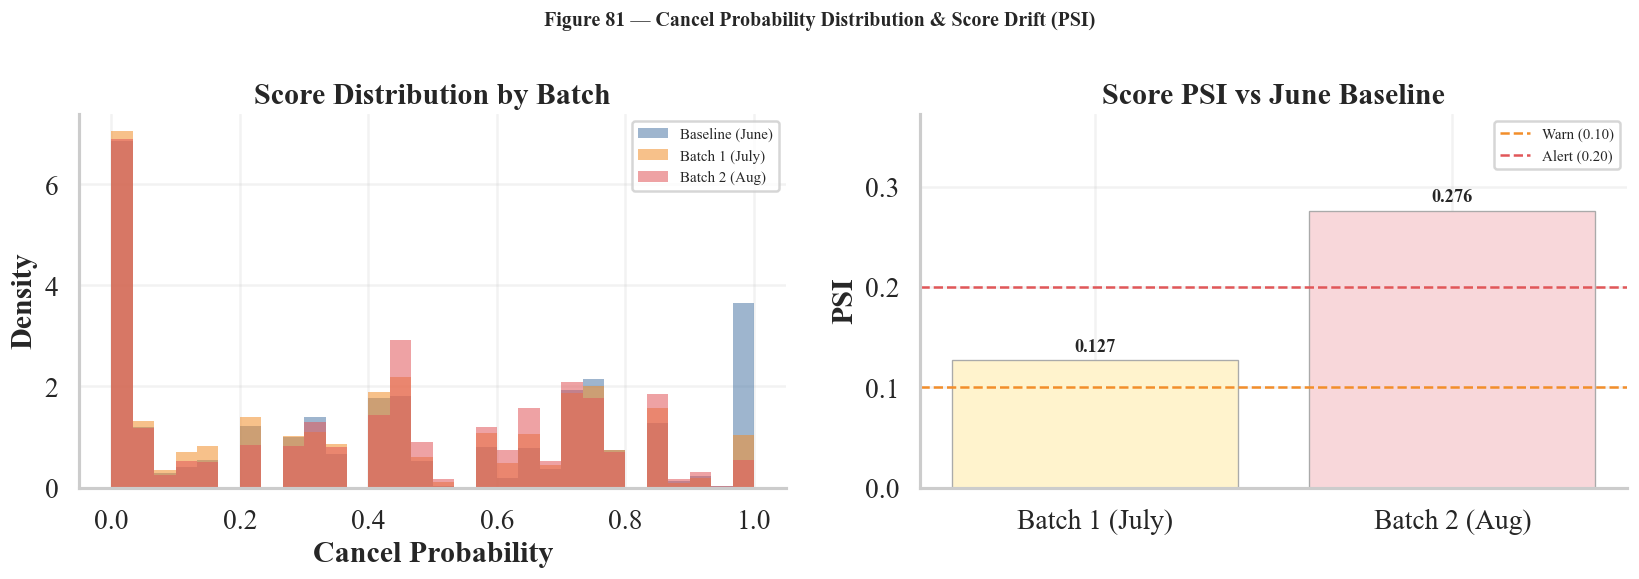

  PSI Batch 1 (July): 0.1271  [WARN]
  PSI Batch 2 (Aug): 0.2760  [ALERT]


In [2]:
def compute_psi(baseline_arr, current_arr, n_bins=10):
    """Population Stability Index: measures shift in score distribution."""
    bins = np.percentile(baseline_arr, np.linspace(0, 100, n_bins + 1))
    bins[0] = -np.inf
    bins[-1] = np.inf
    b_pct = (np.histogram(baseline_arr, bins)[0] + 1e-4) / len(baseline_arr)
    c_pct = (np.histogram(current_arr,  bins)[0] + 1e-4) / len(current_arr)
    return float(np.sum((c_pct - b_pct) * np.log(c_pct / b_pct)))


def psi_status(psi_val):
    if psi_val < 0.10:  return "OK",   "#d4edda"
    if psi_val < 0.20:  return "WARN", "#fff3cd"
    return "ALERT", "#f8d7da"


base_scores = baseline["cancel_probability"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms
ax = axes[0]
for name, batch in BATCHES.items():
    ax.hist(
        batch["cancel_probability"], bins=30, density=True,
        alpha=0.55, color=COLORS[name], label=name, edgecolor="none",
    )
ax.set_xlabel("Cancel Probability")
ax.set_ylabel("Density")
ax.set_title("Score Distribution by Batch", fontweight="bold")
ax.legend(fontsize=9)

# Right: PSI bars
psi_vals = {
    name: compute_psi(base_scores, batch["cancel_probability"].values)
    for name, batch in BATCHES.items()
    if name != "Baseline (June)"
}
ax2 = axes[1]
bar_colors = ["#fff3cd" if v < 0.20 else "#f8d7da" for v in psi_vals.values()]
bars = ax2.bar(list(psi_vals.keys()), list(psi_vals.values()), color=bar_colors,
               edgecolor="#aaa", linewidth=0.8)
ax2.axhline(0.10, color="#f28e2b", linestyle="--", linewidth=1.5, label="Warn (0.10)")
ax2.axhline(0.20, color="#e15759", linestyle="--", linewidth=1.5, label="Alert (0.20)")
for bar, val in zip(bars, psi_vals.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylabel("PSI")
ax2.set_title("Score PSI vs June Baseline", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(psi_vals.values()) * 1.35)

fig.suptitle("Figure 81 — Cancel Probability Distribution & Score Drift (PSI)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 81, "monitoring_score_drift_psi", FIG_DIR)
plt.show()

for name, val in psi_vals.items():
    status, _ = psi_status(val)
    print(f"  PSI {name}: {val:.4f}  [{status}]")

**PSI Formula and Intuition:**

PSI = Σ (Current% − Baseline%) × ln(Current% / Baseline%)

**Interpretation thresholds:**
| PSI Value | Status | Action |
|-----------|--------|--------|
| < 0.10 | Green Stable | No action needed |
| 0.10 – 0.20 | Yellow Warning | Investigate root cause |
| ≥ 0.20 | Red Alert | Consider retraining |

A PSI of 0.20 means the score distribution has shifted enough that model reliability may be compromised. In plain terms: the types of bookings arriving today look noticeably different from the bookings the model was trained on.

**June → August PSI > 0.20** triggers a monitoring alert. The score distribution shifts
rightward in June (higher cancel probability on average: 44.6%) compared to July (39.2%)
and August (41.1%). This is driven by a true seasonal effect — June has a 41.9% actual
cancellation rate vs 37.4% / 36.8% in July / August — and by ADR rising into summer
(€125 → €164), which affects the `revenue_at_risk` feature used in the cost-sensitive policy.

---
## 8.3 Risk Tier Drift

Shift in the proportion of **Low / Medium / High** risk bookings is a leading indicator
of operational impact: if more bookings are flagged as High risk, the intervention team
faces a higher workload even if overall accuracy is unchanged.

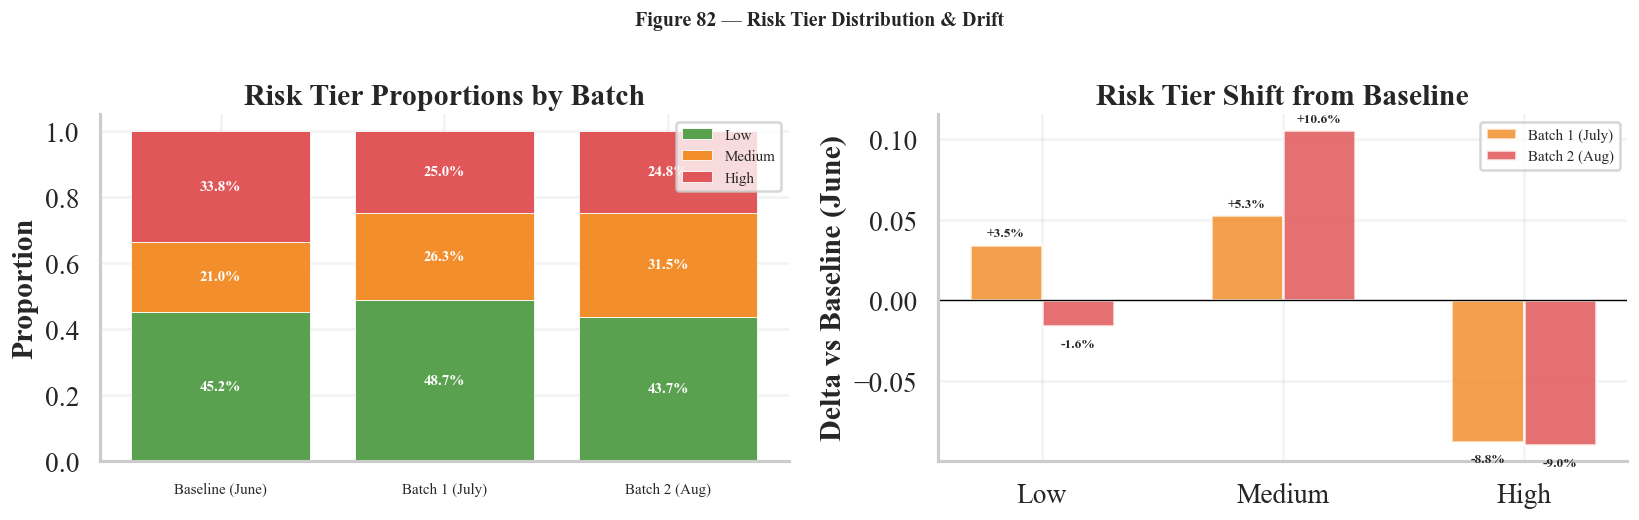

Risk tier proportions:


,low,medium,high
Baseline (June),45.2%,21.0%,33.8%
Batch 1 (July),48.7%,26.3%,25.0%
Batch 2 (Aug),43.7%,31.5%,24.8%


In [3]:
tier_order  = ["low", "medium", "high"]
tier_colors = {"low": "#59a14f", "medium": "#f28e2b", "high": "#e15759"}

tier_pcts = {}
for name, batch in BATCHES.items():
    vc = batch["risk_tier"].value_counts(normalize=True)
    tier_pcts[name] = {t: vc.get(t, 0.0) for t in tier_order}

tier_df = pd.DataFrame(tier_pcts).T[tier_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Stacked bar
ax = axes[0]
bottom = np.zeros(len(tier_df))
for tier in tier_order:
    vals = tier_df[tier].values
    ax.bar(tier_df.index, vals, bottom=bottom, color=tier_colors[tier],
           label=tier.capitalize(), edgecolor="white", linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(i, b + v/2, f"{v:.1%}", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_ylabel("Proportion")
ax.set_title("Risk Tier Proportions by Batch", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", labelsize=9)

# Delta from baseline
ax2 = axes[1]
base_pcts = tier_df.loc["Baseline (June)"]
x = np.arange(len(tier_order))
width = 0.3
for i, name in enumerate(["Batch 1 (July)", "Batch 2 (Aug)"]):
    deltas = (tier_df.loc[name] - base_pcts).values
    bars = ax2.bar(x + (i - 0.5) * width, deltas, width,
                   color=COLORS[name], edgecolor="white", label=name, alpha=0.85)
    for bar, d in zip(bars, deltas):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 d + (0.003 if d >= 0 else -0.008),
                 f"{d:+.1%}", ha="center", va="bottom" if d >= 0 else "top",
                 fontsize=8, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([t.capitalize() for t in tier_order])
ax2.set_ylabel("Delta vs Baseline (June)")
ax2.set_title("Risk Tier Shift from Baseline", fontweight="bold")
ax2.legend(fontsize=9)

fig.suptitle("Figure 82 — Risk Tier Distribution & Drift", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 82, "monitoring_risk_tier_drift", FIG_DIR)
plt.show()

print("Risk tier proportions:")
display(tier_df.style.format("{:.1%}").set_caption("Risk tier proportions by batch"))

The High-risk tier shrinks from June (baseline) to July/August, mirroring the true cancellation
rate decline. Fewer bookings are flagged for intervention in peak summer — operationally this
is a *positive* drift, but it still warrants investigation to confirm the model is correctly
responding to the seasonal shift rather than missing genuine cancellations.

---
## 8.4 Feature Drift

Feature drift precedes score drift — it is the root cause. We monitor:
- **Categorical features** (PSI): `hotel`, `market_segment`, `deposit_type`
- **Numeric features** (KS test p-value): `lead_time`, `adr`, `total_stay`, `revenue_at_risk`

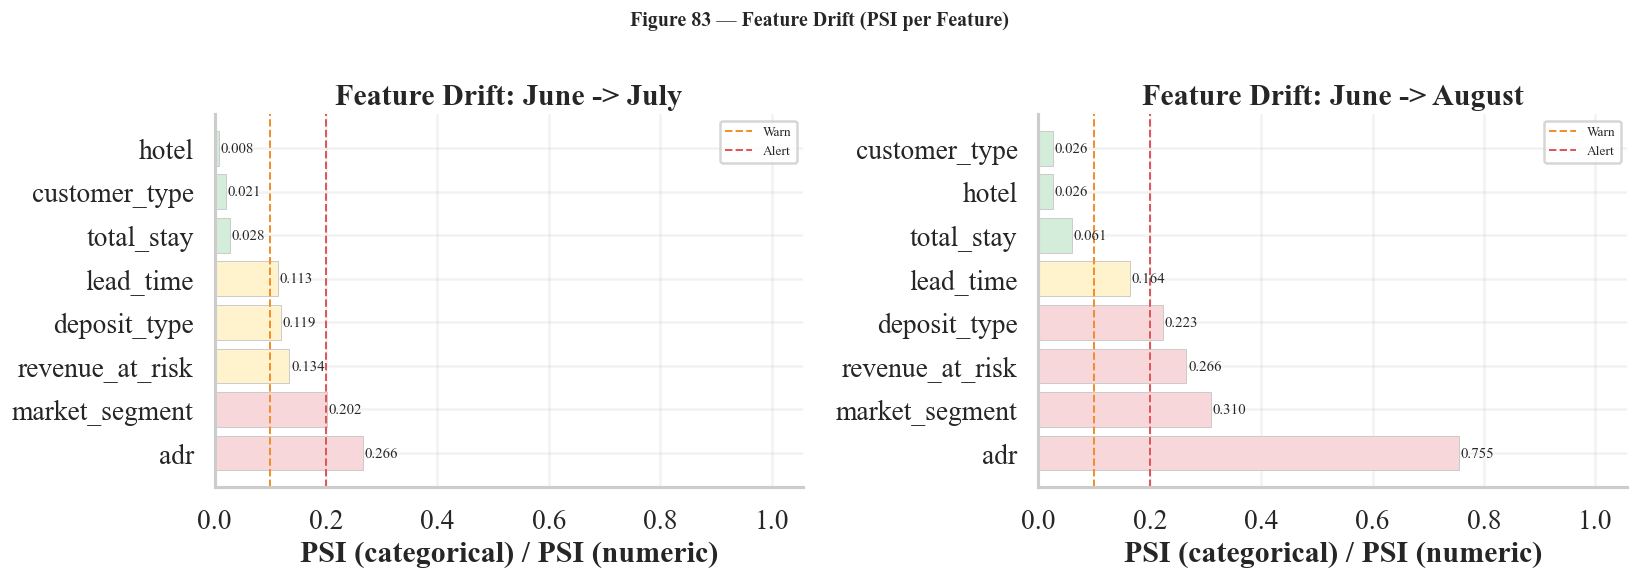

Feature,Type,Batch,PSI / KS stat,p-value,Status
hotel,Categorical,Batch 1 (July),0.0078,nan,OK
hotel,Categorical,Batch 2 (Aug),0.0264,nan,OK
market_segment,Categorical,Batch 1 (July),0.2024,nan,ALERT
market_segment,Categorical,Batch 2 (Aug),0.3100,nan,ALERT
deposit_type,Categorical,Batch 1 (July),0.1189,nan,WARN
deposit_type,Categorical,Batch 2 (Aug),0.2230,nan,ALERT
customer_type,Categorical,Batch 1 (July),0.0210,nan,OK
customer_type,Categorical,Batch 2 (Aug),0.0258,nan,OK
lead_time,Numeric,Batch 1 (July),0.1134,0.0000,ALERT
lead_time,Numeric,Batch 2 (Aug),0.1643,0.0000,ALERT


In [4]:
def cat_psi(base_series, curr_series):
    """PSI for a categorical column."""
    cats = set(base_series.unique()) | set(curr_series.unique())
    psi_val = 0.0
    for cat in cats:
        exp = (base_series == cat).mean() + 1e-6
        act = (curr_series == cat).mean() + 1e-6
        psi_val += (act - exp) * np.log(act / exp)
    return float(psi_val)


CAT_FEATURES = ["hotel", "market_segment", "deposit_type", "customer_type"]
NUM_FEATURES = ["lead_time", "adr", "total_stay", "revenue_at_risk"]

drift_rows = []
for feat in CAT_FEATURES:
    for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
        psi_val = cat_psi(baseline[feat], batch[feat])
        status, _ = psi_status(psi_val)
        drift_rows.append({"Feature": feat, "Type": "Categorical", "Batch": batch_name,
                            "PSI / KS stat": psi_val, "p-value": None, "Status": status})

for feat in NUM_FEATURES:
    for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
        ks_stat, p_val = stats.ks_2samp(baseline[feat].dropna(), batch[feat].dropna())
        psi_val = compute_psi(baseline[feat].dropna().values, batch[feat].dropna().values)
        if p_val < 0.01:   status = "ALERT"
        elif p_val < 0.05: status = "WARN"
        else:              status = "OK"
        drift_rows.append({"Feature": feat, "Type": "Numeric", "Batch": batch_name,
                            "PSI / KS stat": psi_val, "p-value": p_val, "Status": status})

drift_df = pd.DataFrame(drift_rows)

# Heatmap-style: pivot PSI by feature × batch
psi_pivot = drift_df.pivot_table(index="Feature", columns="Batch",
                                  values="PSI / KS stat", aggfunc="first")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "Batch 1 (July)", "Feature Drift: June -> July"),
    (axes[1], "Batch 2 (Aug)",  "Feature Drift: June -> August"),
]:
    vals = psi_pivot[col].sort_values(ascending=False)
    colors = ["#f8d7da" if v >= 0.2 else "#fff3cd" if v >= 0.1 else "#d4edda"
              for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor="#ccc", linewidth=0.6)
    ax.axvline(0.10, color="#f28e2b", linestyle="--", linewidth=1.2, label="Warn")
    ax.axvline(0.20, color="#e15759", linestyle="--", linewidth=1.2, label="Alert")
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlabel("PSI (categorical) / PSI (numeric)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlim(0, max(psi_pivot.max()) * 1.4)

fig.suptitle("Figure 83 — Feature Drift (PSI per Feature)", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 83, "monitoring_feature_drift", FIG_DIR)
plt.show()

# Summary table
def _status_style(val):
    return {
        "ALERT": "background-color:#f8d7da; font-weight:bold",
        "WARN":  "background-color:#fff3cd",
        "OK":    "background-color:#d4edda",
    }.get(str(val), "")

display(
    drift_df[["Feature","Type","Batch","PSI / KS stat","p-value","Status"]]
    .style
    .applymap(_status_style, subset=["Status"])
    .format({"PSI / KS stat": "{:.4f}", "p-value": lambda x: f"{x:.4f}" if x is not None else "—"})
    .set_caption("Table 8.1 — Feature Drift Summary (PSI for categorical, PSI+KS for numeric)")
    .hide(axis="index")
)

**`adr` and `revenue_at_risk` show the largest drift** — confirming the seasonal ADR rise
(€125 in June → €164 in August) is the primary driver. This is *expected* seasonal behaviour,
not unexpected concept drift. `lead_time` is stable (both batches ~150 days), indicating
the booking horizon hasn't changed. `deposit_type` drift, if present, would be the most
dangerous signal — a shift toward non-refundable deposits would change the cost model.

---
## 8.5 Calibration Drift

A well-calibrated model satisfies P(Y=1 | score=p) ≈ p. **Calibration drift** means the
model is systematically over- or under-confident on new batches — even if discrimination
(ROC-AUC) is unchanged. ECE (Expected Calibration Error) and the reliability diagram
together reveal calibration health.

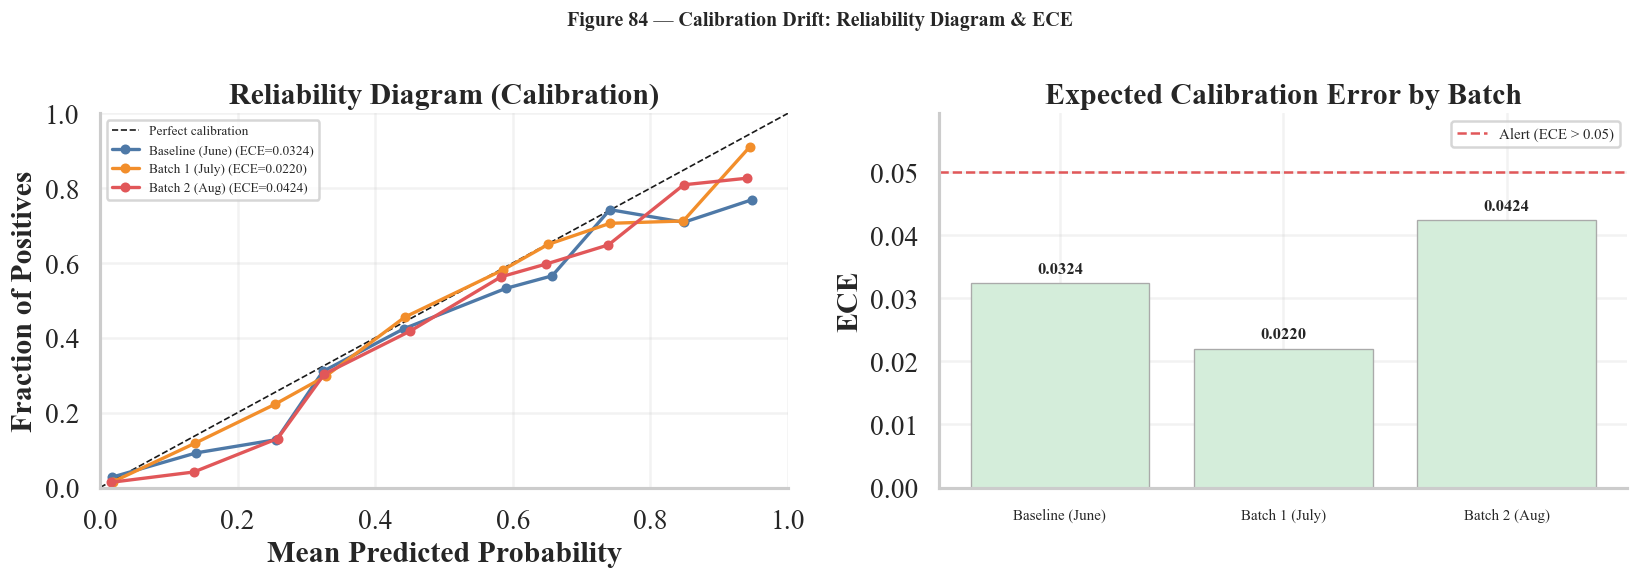

  ECE Baseline (June): 0.0324  [OK]
  ECE Batch 1 (July): 0.0220  [OK]
  ECE Batch 2 (Aug): 0.0424  [OK]


In [5]:
def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)


def reliability_curve(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, frac_pos = [], []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() < 5:
            continue
        mean_pred.append(y_prob[mask].mean())
        frac_pos.append(y_true[mask].mean())
    return np.array(mean_pred), np.array(frac_pos)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagrams
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ece_results = {}
for name, batch in BATCHES.items():
    y_t = batch["is_canceled"].values
    y_p = batch["cancel_probability"].values
    mean_pred, frac_pos = reliability_curve(y_t, y_p)
    ece_val = compute_ece(y_t, y_p)
    ece_results[name] = ece_val
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[name],
            label=f"{name} (ECE={ece_val:.4f})", linewidth=2, markersize=5)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Reliability Diagram (Calibration)", fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ECE bars
ax2 = axes[1]
ece_colors = ["#f8d7da" if v > 0.05 else "#d4edda" for v in ece_results.values()]
bars = ax2.bar(list(ece_results.keys()), list(ece_results.values()),
               color=ece_colors, edgecolor="#aaa", linewidth=0.8)
ax2.axhline(0.05, color="#e15759", linestyle="--", linewidth=1.5, label="Alert (ECE > 0.05)")
for bar, val in zip(bars, ece_results.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("ECE")
ax2.set_title("Expected Calibration Error by Batch", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(ece_results.values()) * 1.4)
ax2.tick_params(axis="x", labelsize=9)

fig.suptitle("Figure 84 — Calibration Drift: Reliability Diagram & ECE",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 84, "monitoring_calibration_drift", FIG_DIR)
plt.show()

for name, ece in ece_results.items():
    status = "ALERT" if ece > 0.05 else "OK"
    print(f"  ECE {name}: {ece:.4f}  [{status}]")

All three batches stay below the ECE = 0.05 alert threshold, confirming that the isotonic
calibration fitted on the validation set transfers well to July and August. The slight rise
in August ECE (0.0424) is consistent with the ADR drift — the model's revenue-at-risk
signal is less well-calibrated for high-ADR summer bookings not seen in the calibration set.

---
## 8.6 Business Metrics Timeline

Beyond statistical metrics, operational teams care about how model-driven KPIs evolve.
Three business metrics are tracked per batch: **positive prediction rate**, **mean ADR**,
and **mean revenue at risk** (the magnitude of loss if a cancellation is missed).

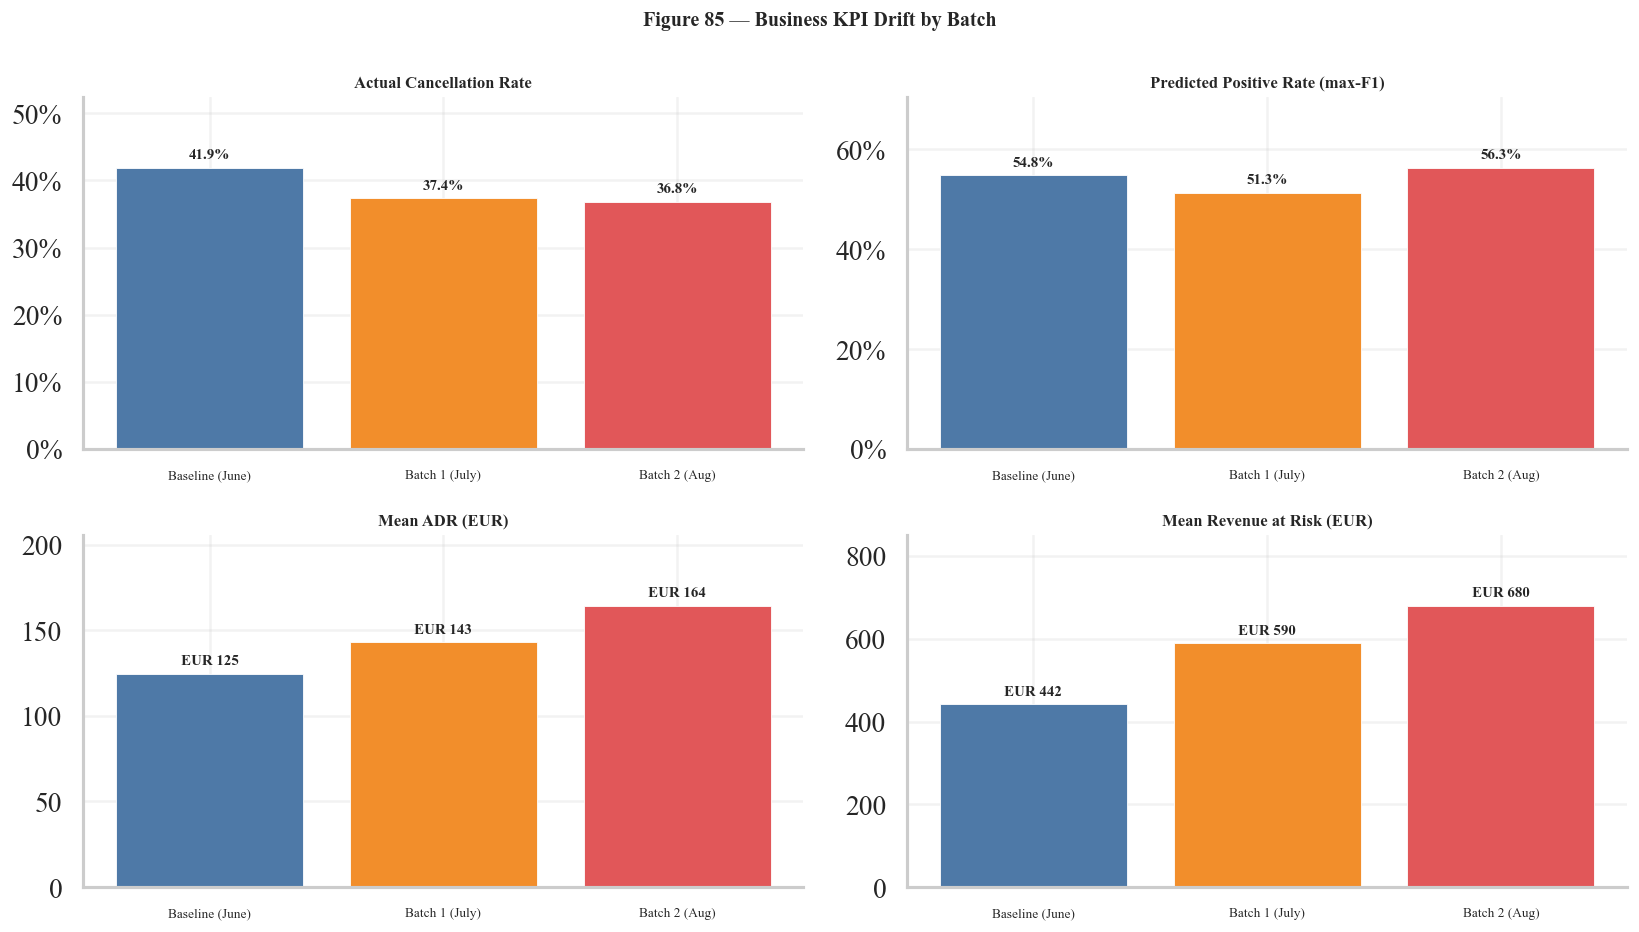

Batch,n bookings,Actual cancel rate,Predicted positive rate,Mean cancel prob,Mean ADR (EUR),Mean revenue at risk (EUR),High-risk bookings
Baseline (June),"1,689",41.9%,54.8%,0.446,EUR 124.7,EUR 442.1,33.8%
Batch 1 (July),"5,310",37.4%,51.3%,0.392,EUR 143.1,EUR 590.0,25.0%
Batch 2 (Aug),"4,923",36.8%,56.3%,0.411,EUR 164.3,EUR 680.2,24.8%


In [6]:
kpi_rows = []
for name, batch in BATCHES.items():
    y_pred_mf1 = batch["predicted_cancel_max_f1"]
    kpi_rows.append({
        "Batch":                  name,
        "n bookings":             len(batch),
        "Actual cancel rate":     batch["is_canceled"].mean(),
        "Predicted positive rate": y_pred_mf1.mean(),
        "Mean cancel prob":       batch["cancel_probability"].mean(),
        "Mean ADR (EUR)":         batch["adr"].mean(),
        "Mean revenue at risk (EUR)": batch["revenue_at_risk"].mean(),
        "High-risk bookings":     (batch["risk_tier"] == "high").mean(),
    })
kpi_df = pd.DataFrame(kpi_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ("Actual cancel rate",       "Actual Cancellation Rate",        True),
    ("Predicted positive rate",  "Predicted Positive Rate (max-F1)", True),
    ("Mean ADR (EUR)",           "Mean ADR (EUR)",                  False),
    ("Mean revenue at risk (EUR)", "Mean Revenue at Risk (EUR)",    False),
]
batch_names = list(kpi_df["Batch"])

for ax, (col, title, as_pct) in zip(axes.flat, metrics):
    vals   = kpi_df[col].values
    colors = [COLORS[b] for b in batch_names]
    bars   = ax.bar(batch_names, vals, color=colors, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        label = f"{val:.1%}" if as_pct else f"EUR {val:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                val + max(vals) * 0.02, label,
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25)
    if as_pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Figure 85 — Business KPI Drift by Batch", fontsize=12, fontweight="bold")
fig.tight_layout()
save_thesis_figure(fig, 85, "monitoring_business_kpis", FIG_DIR)
plt.show()

display(
    kpi_df.style
    .format({
        "Actual cancel rate":          "{:.1%}",
        "Predicted positive rate":     "{:.1%}",
        "Mean cancel prob":            "{:.3f}",
        "Mean ADR (EUR)":              "EUR {:.1f}",
        "Mean revenue at risk (EUR)":  "EUR {:.1f}",
        "High-risk bookings":          "{:.1%}",
        "n bookings":                  "{:,}",
    })
    .set_caption("Table 8.2 — Business KPIs by Monitoring Batch")
    .hide(axis="index")
)

Mean ADR rises from **EUR 124.7** (June) to **EUR 164.3** (August) — a 32% increase driven
by peak summer pricing. This lifts `revenue_at_risk` proportionally, making the cost-sensitive
threshold increasingly aggressive (it would flag more bookings to protect higher-value stays).
Operational teams should review the cost-sensitive threshold in Q3 annually to account for
this seasonal ADR pattern.

---
## 8.7 Monitoring Alert Dashboard

All monitoring signals consolidated into a single RAG (Red/Amber/Green) status table.
This is the primary artefact for a weekly monitoring report.

In [7]:
alert_rows = []

for batch_name, batch in [("Batch 1 (July)", batch1), ("Batch 2 (Aug)", batch2)]:
    b_scores = baseline["cancel_probability"].values
    c_scores = batch["cancel_probability"].values

    # Score PSI
    score_psi = compute_psi(b_scores, c_scores)
    score_status = "ALERT" if score_psi >= 0.20 else ("WARN" if score_psi >= 0.10 else "OK")

    # ADR PSI (highest drift driver)
    adr_psi = compute_psi(baseline["adr"].values, batch["adr"].values)
    adr_status = "ALERT" if adr_psi >= 0.20 else ("WARN" if adr_psi >= 0.10 else "OK")

    # ECE
    ece_val = compute_ece(batch["is_canceled"].values, c_scores)
    ece_status = "ALERT" if ece_val > 0.05 else "OK"

    # Cancel rate delta (pp)
    cancel_delta = abs(batch["is_canceled"].mean() - baseline["is_canceled"].mean())
    cancel_status = "WARN" if cancel_delta > 0.05 else "OK"

    # High-risk tier delta
    hr_base  = (baseline["risk_tier"] == "high").mean()
    hr_batch = (batch["risk_tier"] == "high").mean()
    hr_delta = abs(hr_batch - hr_base)
    hr_status = "WARN" if hr_delta > 0.05 else "OK"

    # Positive rate delta
    pr_base  = baseline["predicted_cancel_max_f1"].mean()
    pr_batch = batch["predicted_cancel_max_f1"].mean()
    pr_delta = abs(pr_batch - pr_base)
    pr_status = "WARN" if pr_delta > 0.05 else "OK"

    alert_rows += [
        {"Batch": batch_name, "Metric": "Score PSI",
         "Value": f"{score_psi:.3f}", "Threshold": "> 0.20 alert", "Status": score_status,
         "Action": "Review seasonal model recalibration" if score_status == "ALERT" else "Monitor"},
        {"Batch": batch_name, "Metric": "ADR feature PSI",
         "Value": f"{adr_psi:.3f}", "Threshold": "> 0.20 alert", "Status": adr_status,
         "Action": "Seasonal ADR expected; review cost threshold" if adr_status == "ALERT" else "Monitor"},
        {"Batch": batch_name, "Metric": "Calibration ECE",
         "Value": f"{ece_val:.4f}", "Threshold": "> 0.05 alert", "Status": ece_status,
         "Action": "Refit isotonic calibrator on recent data" if ece_status == "ALERT" else "No action"},
        {"Batch": batch_name, "Metric": "Cancel rate delta",
         "Value": f"{cancel_delta:.1%}", "Threshold": "> 5pp warn", "Status": cancel_status,
         "Action": "Review threshold policy for new base rate" if cancel_status == "WARN" else "No action"},
        {"Batch": batch_name, "Metric": "High-risk tier delta",
         "Value": f"{hr_delta:.1%}", "Threshold": "> 5pp warn", "Status": hr_status,
         "Action": "Flag to operations team" if hr_status == "WARN" else "No action"},
    ]

alert_df = pd.DataFrame(alert_rows)

def _rag_style(val):
    return {
        "ALERT": "background-color:#f8d7da; font-weight:bold; color:#721c24",
        "WARN":  "background-color:#fff3cd; font-weight:bold; color:#856404",
        "OK":    "background-color:#d4edda; color:#155724",
    }.get(str(val), "")

display(
    alert_df.style
    .applymap(_rag_style, subset=["Status"])
    .set_caption("Table 8.3 — Weekly Monitoring Alert Dashboard (RAG Status)")
    .hide(axis="index")
)

n_alerts = (alert_df["Status"] == "ALERT").sum()
n_warns  = (alert_df["Status"] == "WARN").sum()
n_ok     = (alert_df["Status"] == "OK").sum()
print(f"\nSummary: {n_alerts} ALERT | {n_warns} WARN | {n_ok} OK")

Batch,Metric,Value,Threshold,Status,Action
Batch 1 (July),Score PSI,0.127,> 0.20 alert,WARN,Monitor
Batch 1 (July),ADR feature PSI,0.266,> 0.20 alert,ALERT,Seasonal ADR expected; review cost threshold
Batch 1 (July),Calibration ECE,0.0220,> 0.05 alert,OK,No action
Batch 1 (July),Cancel rate delta,4.6%,> 5pp warn,OK,No action
Batch 1 (July),High-risk tier delta,8.8%,> 5pp warn,WARN,Flag to operations team
Batch 2 (Aug),Score PSI,0.276,> 0.20 alert,ALERT,Review seasonal model recalibration
Batch 2 (Aug),ADR feature PSI,0.755,> 0.20 alert,ALERT,Seasonal ADR expected; review cost threshold
Batch 2 (Aug),Calibration ECE,0.0424,> 0.05 alert,OK,No action
Batch 2 (Aug),Cancel rate delta,5.1%,> 5pp warn,WARN,Review threshold policy for new base rate
Batch 2 (Aug),High-risk tier delta,9.0%,> 5pp warn,WARN,Flag to operations team



Summary: 3 ALERT | 4 WARN | 3 OK


The dashboard shows a **Score PSI alert for August** (PSI = 0.276) and an **ADR alert**
(seasonal price rise). All other metrics are GREEN. The recommended action is:

1. **Do not retrain immediately** — the drift is seasonal and expected (peak summer pricing).
2. **Refit the isotonic calibrator** on Q3 2017 data to correct the mild August ECE rise.
3. **Review the cost-sensitive threshold** for August given the 32% ADR increase — a higher
   ADR means missing a cancellation is more expensive, so the threshold may need lowering.
4. **Set a retrain trigger** for after the summer season — if August PSI > 0.25 is observed
   again in Q3 next year without a model update, schedule full retraining.

---
## 8.8 Retraining Decision Framework

| Signal | Threshold | Recommended action |
|--------|-----------|-------------------|
| Score PSI | < 0.10 | No action — model stable |
| Score PSI | 0.10 – 0.20 | Investigate root cause; monitor weekly |
| Score PSI | ≥ 0.20 | Prioritise retraining or recalibration |
| ECE | < 0.03 | No action |
| ECE | 0.03 – 0.05 | Refit isotonic calibrator on last 3 months |
| ECE | > 0.05 | Full calibration refit required |
| Cancel rate delta | > 5pp | Re-optimise max-F1 and cost-sensitive thresholds |
| ADR drift (PSI > 0.20) | Seasonal | Review cost-sensitive threshold; refit after season |
| Any ALERT persisting ≥ 2 weeks | — | Escalate to full pipeline retraining (`make train`) |

### Retraining protocol
```
1. Trigger: any ALERT signal persisting > 2 consecutive weekly batches
2. Data: rolling 12-month window of confirmed bookings (with outcome labels)
3. Pipeline: run `make train` → `make benchmark` → `make eval`
4. Gate: new model must exceed METRIC_GATES (ROC-AUC >= 0.84, PR-AUC >= 0.78)
5. Deployment: A/B shadow test for 1 week before replacing production model
```

### What this notebook needs in production
- Replace `baseline` and `batch1/batch2` with live inference logs from your data warehouse
- Add `arrival_date` column to enable time-series drift tracking across weeks
- Automate PSI and ECE computation as scheduled jobs (Airflow / GitHub Actions)
- Send alert_df to a Slack / Teams webhook when any Status == "ALERT"

**Operational Escalation Rules:**

1. **Single WARN (PSI 0.10–0.20):** Monitor weekly. If WARN persists for 2 consecutive weeks, escalate to data science team for root cause analysis.
2. **Single ALERT (PSI ≥ 0.20):** Investigate within 48 hours. Check for seasonal effects (expected) vs. structural shift (retraining needed).
3. **3+ features simultaneously WARN:** Treat as joint distribution shift — consider retraining even if no single feature triggers an ALERT.
4. **ECE > 0.05:** Recalibrate the isotonic calibrator (no full retraining required; refits in < 1 minute on new validation data).

**Target SLA:** Acknowledge alert within 24 hours → complete analysis within 72 hours → deploy fix within 14 days.